## **MODELS3. Fine-tuning de SmolVLM-500M para clasificación de natación artística.**

El cuaderno incluye:

- Carga y exploración del dataset aumentado de natación artística sincronizada (5 clases).
- Fine-tuning de **SmolVLM-500M-Instruct** mediante adaptadores **LoRA** para clasificación de posiciones corporales.
- Clasificación por **logits de elección múltiple** (tokens `S=Bent Knee Surface Arch`, `V=Bent Knee Vertical`, `D=Double Leg Vertical`, `F=Fishtail`, `K=Knight`) en lugar de generación libre de texto.
- Evaluación sobre conjunto de test: accuracy, matriz de confusión e informe de clasificación.
- Visualización de predicciones de muestra con confianza asociada.
- Guardado del adaptador LoRA entrenado para reutilización posterior.

El cuaderno implementa un pipeline completo de fine-tuning multimodal sobre un VLM pequeño. Se ejecuta de manera independiente y en orden; es autocontenido e incluye la carga de datos, preprocesado, entrenamiento, evaluación y exportación del modelo.

---

#### **1. Importaciones y configuración global**

In [15]:
import random
import warnings
from pathlib import Path
import time, platform, sys

warnings.filterwarnings('ignore')

import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
from tqdm.auto import tqdm

from transformers import AutoProcessor, AutoModelForImageTextToText
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Rutas ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.')
DATA_DIR     = NOTEBOOK_DIR / '..' / 'Data'
CSV_PATH      = DATA_DIR / 'synchronized_swimming_aug.csv'  # aumentadas
CSV_ORIG_PATH = DATA_DIR / 'synchronized_swimming.csv'      # original
MODEL_SAVE   = NOTEBOOK_DIR / 'smolvlm_lora_natacion'

# ── Modelo ────────────────────────────────────────────────────────────────────
MODEL_ID = 'HuggingFaceTB/SmolVLM-500M-Instruct'

# ── Opciones de elección múltiple ─────────────────────────────────────────────
# Cada token debe ser único y de un solo carácter para que el mecanismo de
# logits pueda distinguirlos. Se usa la inicial más distintiva de cada clase:
#   S → Bent Knee Surface Arch Position  (S de Surface/Arch)
#   V → Bent Knee Vertical               (V de Vertical)
#   D → Double Leg Vertical              (D de Double)
#   F → Fishtail                         (F de Fishtail)
#   K → Knight                           (K de Knight)

CHOICE_LABELS = ['S', 'V', 'D', 'F', 'K']

# Abreviaciones para mostrar en gráficas (confusión, predicciones, etc.)
ABREV = {
    'Bent Knee Surface Arch Position': 'BKSA',
    'Bent Knee Vertical':              'BKV',
    'Double Leg Vertical':             'DLV',
    'Fishtail':                        'FT',
    'Knight':                          'KT',
}

# ── Subconjunto para primera prueba (None = dataset completo) ─────────────────
SUBSET_TRAIN_PER_CLASS = 60   # imágenes de entrenamiento por clase
SUBSET_VAL_PER_CLASS   = 20   # imágenes de validación por clase
SUBSET_TEST_PER_CLASS  = 30   # imágenes de test por clase

# ── Hiperparámetros ──────────────────────────────────────────────────────────
SEED        = 42
BATCH_SIZE  = 2       # SmolVLM necesita más memoria que BLIP; 2 es seguro
NUM_EPOCHS  = 5
LR          = 2e-4
MAX_LENGTH  = 256     # tokens máximos por secuencia (imagen + prompt)
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05

# ── Reproducibilidad ─────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print(f'Dispositivo: {DEVICE}  |  dtype: {DTYPE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}  |  VRAM: {props.total_memory / 1e9:.1f} GB')
print(f'Modelo: {MODEL_ID}')
print(f'Subconjunto train: {SUBSET_TRAIN_PER_CLASS} imgs/clase · '
      f'val: {SUBSET_VAL_PER_CLASS} imgs/clase · '
      f'test: {SUBSET_TEST_PER_CLASS} imgs/clase')

Dispositivo: cpu  |  dtype: torch.float32
Modelo: HuggingFaceTB/SmolVLM-500M-Instruct
Subconjunto train: 60 imgs/clase · val: 20 imgs/clase · test: 30 imgs/clase


#### **2. Carga del dataset**

In [16]:
def cargar_dataset(csv_path: Path, base_dir: Path) -> pd.DataFrame:
    """
    Carga el CSV de natación artística, resuelve rutas absolutas y filtra
    imágenes que no existen en disco.

    Args:
        csv_path: Ruta al CSV con columnas (filepath, label).
        base_dir: Directorio base desde el que se resuelven las rutas relativas.

    Returns:
        DataFrame con columnas ['filepath', 'label', 'abs_path'].
    """
    csv_path = Path(csv_path)
    base_dir = Path(base_dir).resolve()

    if not csv_path.exists():
        raise FileNotFoundError(f'CSV no encontrado: {csv_path.resolve()}')

    df = pd.read_csv(csv_path)
    df['abs_path'] = df['filepath'].apply(
        lambda p: (base_dir / Path(p.replace('\\', '/'))).resolve()
    )

    mask = df['abs_path'].apply(lambda p: p.exists())
    n_omitidas = (~mask).sum()
    df = df[mask].reset_index(drop=True)

    if n_omitidas > 0:
        print(f'Advertencia: {n_omitidas} imágenes omitidas (archivo no encontrado).')
    if df.empty:
        raise RuntimeError('No se encontraron imágenes válidas. Verifica DATA_DIR.')

    print(f'Dataset cargado: {len(df):,} imágenes · {df["label"].nunique()} clases')
    return df


df = cargar_dataset(CSV_PATH, DATA_DIR)             # aumentadas (para CLASES, mapas, etc.)
df_aug = df                                         # alias explícito para la fase de split
df_orig = cargar_dataset(CSV_ORIG_PATH, DATA_DIR)   # originales (base del split)

CLASES = sorted(df['label'].unique().tolist())
print(f'\nClases ({len(CLASES)}):')
for i, cls in enumerate(CLASES):
    n = (df['label'] == cls).sum()
    print(f'  ({CHOICE_LABELS[i]}) {cls}: {n} imágenes')

# Mapas clase <-> índice y clase <-> letra
CLS2IDX = {cls: i for i, cls in enumerate(CLASES)}
IDX2CLS = {i: cls for i, cls in enumerate(CLASES)}
CLS2LETTER = {cls: CHOICE_LABELS[i] for i, cls in enumerate(CLASES)}
LETTER2CLS = {CHOICE_LABELS[i]: cls for i, cls in enumerate(CLASES)}

Dataset cargado: 6,575 imágenes · 5 clases
Dataset cargado: 263 imágenes · 5 clases

Clases (5):
  (S) Bent Knee Surface Arch Position: 975 imágenes
  (V) Bent Knee Vertical: 1300 imágenes
  (D) Double Leg Vertical: 1250 imágenes
  (F) Fishtail: 1475 imágenes
  (K) Knight: 1575 imágenes


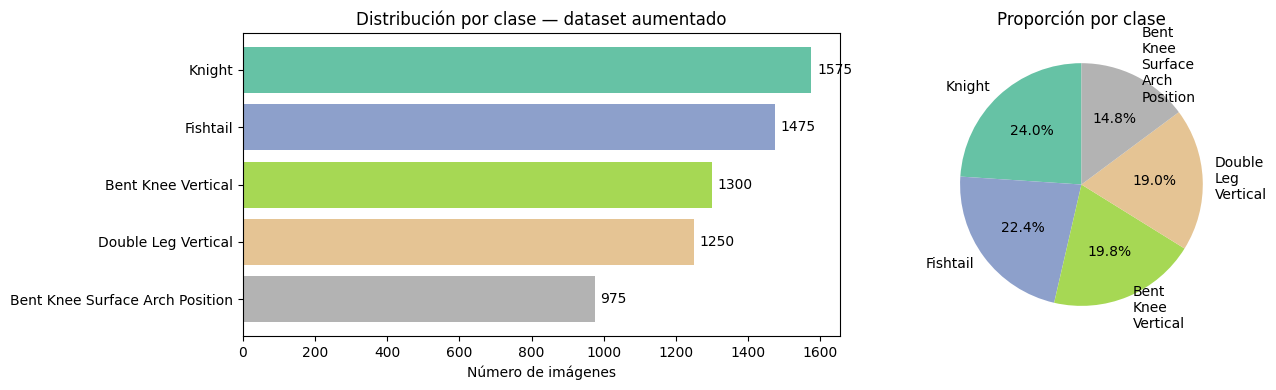

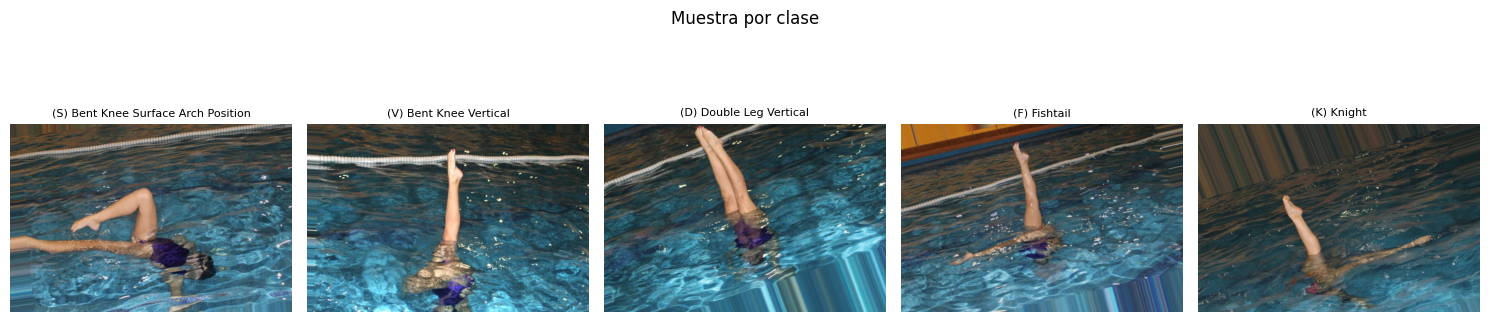

In [17]:
# ── Distribución de clases y muestra de imágenes ──────────────────────────────
conteos = df['label'].value_counts()
colores = plt.cm.Set2(np.linspace(0, 1, len(CLASES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barras de distribución
barras = axes[0].barh(conteos.index, conteos.values, color=colores)
axes[0].bar_label(barras, padding=4, fontsize=10)
axes[0].set_xlabel('Número de imágenes')
axes[0].set_title('Distribución por clase — dataset aumentado')
axes[0].invert_yaxis()

# Tarta de porcentajes
axes[1].pie(conteos.values, labels=[c.replace(' ', '\n') for c in conteos.index],
            colors=colores, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.show()


# Una imagen de muestra por clase
fig2, sample_axes = plt.subplots(1, len(CLASES), figsize=(15, 4))
for ax, (cls, color) in zip(sample_axes, zip(CLASES, colores)):
    muestra = df[df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(muestra['abs_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'({CLS2LETTER[cls]}) {cls}', fontsize=8)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle('Muestra por clase', fontsize=12)
plt.tight_layout()
plt.show()

#### **3. División del dataset y creación de subconjunto balanceado**

Se realiza primero una partición estratificada completa (70/15/15) y, tras comprobar en algunas pruebas que se requieren recursos aumentados que se salen del alcance académico en el que se trabaja, se extrae un subconjunto pequeño y balanceado entre clases que servirá como dataset para la ejecución del modelo. Se busca obtener una primera intuición de su funcionamiento. 

Para usar el dataset completo en caso de disponer de los recursos necesarios, basta con cambiar `SUBSET_*_PER_CLASS = None` en la celda de configuración global.

In [18]:
# LabelEncoder sobre originales (mismas clases que las aumentadas)
le = LabelEncoder()
df_orig['label_enc'] = le.fit_transform(df_orig['label'])

# Índice: stem original → filas aumentadas correspondientes
df_aug['_stem'] = df_aug['filepath'].apply(
    lambda p: re.sub(r'_aug\d+$', '', Path(p.replace('\\', '/')).stem)
)
aug_index = df_aug.groupby('_stem')

# ── Split estratificado sobre originales (70 / 15 / 15) ──────────────────────
orig_trainval, orig_test = train_test_split(
    df_orig, test_size=TEST_RATIO, stratify=df_orig['label_enc'], random_state=SEED
)
orig_train, orig_val = train_test_split(
    orig_trainval,
    test_size=VAL_RATIO / (1.0 - TEST_RATIO),
    stratify=orig_trainval['label_enc'],
    random_state=SEED,
)

# ── Expandir cada partición con 15 aumentaciones por imagen original ──────────
def expand_with_augmentations(split_df: pd.DataFrame, n_aug: int = 15) -> pd.DataFrame:
    extras = []
    for fp in split_df['filepath']:
        stem = Path(fp.replace('\\', '/')).stem
        if stem in aug_index.groups:
            group = aug_index.get_group(stem).drop(columns='_stem')
            extras.append(group.sample(n=min(n_aug, len(group)), random_state=SEED))
    aug_block = (
        pd.concat(extras, ignore_index=True)
        if extras
        else pd.DataFrame(columns=['filepath', 'label', 'abs_path'])
    )
    base = split_df.drop(columns='label_enc').reset_index(drop=True)
    return pd.concat([base, aug_block], ignore_index=True)

df_train_full = expand_with_augmentations(orig_train)
df_val_full   = expand_with_augmentations(orig_val)
df_test_full  = expand_with_augmentations(orig_test)

print('División:')
for nombre, orig, full in [
    ('Train', orig_train, df_train_full),
    ('Val',   orig_val,   df_val_full),
    ('Test',  orig_test,  df_test_full),
]:
    print(f'  {nombre:>5}: {len(full):>5}  ({len(orig)} orig + {len(full)-len(orig)} aug)')

# ── Subconjunto de trabajo (si SUBSET_*_PER_CLASS != None) ───────────────────
def extraer_subset(df_split: pd.DataFrame, n_por_clase: int | None) -> pd.DataFrame:
    if n_por_clase is None:
        return df_split.copy()
    return pd.concat([
        df_split.loc[df_split['label'] == cls, ['filepath', 'label', 'abs_path']]
        .sample(min(n_por_clase, int((df_split['label'] == cls).sum())), random_state=SEED)
        for cls in CLASES
    ]).reset_index(drop=True)

df_train = extraer_subset(df_train_full, SUBSET_TRAIN_PER_CLASS)
df_val   = extraer_subset(df_val_full,   SUBSET_VAL_PER_CLASS)
df_test  = extraer_subset(df_test_full,  SUBSET_TEST_PER_CLASS)

print(f'\nSubconjunto de trabajo:')
for nombre, subdf in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = subdf['label'].value_counts()
    print(f'  {nombre:>5}: {len(subdf):>4} imágenes  ({dict(dist)})')

División:
  Train:  2928  (183 orig + 2745 aug)
    Val:   640  (40 orig + 600 aug)
   Test:   640  (40 orig + 600 aug)

Subconjunto de trabajo:
  Train:  300 imágenes  ({'Bent Knee Surface Arch Position': np.int64(60), 'Bent Knee Vertical': np.int64(60), 'Double Leg Vertical': np.int64(60), 'Fishtail': np.int64(60), 'Knight': np.int64(60)})
    Val:  100 imágenes  ({'Bent Knee Surface Arch Position': np.int64(20), 'Bent Knee Vertical': np.int64(20), 'Double Leg Vertical': np.int64(20), 'Fishtail': np.int64(20), 'Knight': np.int64(20)})
   Test:  150 imágenes  ({'Bent Knee Surface Arch Position': np.int64(30), 'Bent Knee Vertical': np.int64(30), 'Double Leg Vertical': np.int64(30), 'Fishtail': np.int64(30), 'Knight': np.int64(30)})


#### **4. Carga de SmolVLM-500M-Instruct + LoRA**

Se desactiva el `image_splitting` del procesador para que cada imagen
produzca un número **fijo** de tokens visuales, lo que permite apilar
los tensores en batches con padding estándar.

**LoRA** se aplica sobre las proyecciones `q_proj` y `v_proj` de
**todas** las capas de atención (vision encoder + language model),
actualizando solo ~1 % de los parámetros totales.

In [19]:
print(f'Cargando procesador: {MODEL_ID} ...')
processor = AutoProcessor.from_pretrained(MODEL_ID)

# Desactivar image splitting → tokens visuales de longitud fija por imagen
if hasattr(processor, 'image_processor') and hasattr(processor.image_processor, 'do_image_splitting'):
    processor.image_processor.do_image_splitting = False
    print('  image_splitting desactivado (tokens visuales fijos)')

# Left-padding: el logit de interés siempre queda en la posición -1
processor.tokenizer.padding_side = 'left'
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

print('Procesador listo.\n')

# ── Cargar modelo base ────────────────────────────────────────────────────────
print(f'Cargando modelo: {MODEL_ID}  (primera vez descarga ~1 GB) ...')
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
)
model = model.to(DEVICE)
print('Modelo base cargado.\n')

# ── Configuración LoRA ────────────────────────────────────────────────────────
# target_modules=['q_proj','v_proj'] afecta a TODAS las capas del modelo
# (tanto vision encoder como language model), maximizando la adaptación
# con un coste de parámetros contenido.
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.FEATURE_EXTRACTION,   # no sobreescribe generate()
    target_modules=['q_proj', 'v_proj'],
)

model = get_peft_model(model, lora_config)

params_total       = sum(p.numel() for p in model.parameters())
params_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:       {params_total:>12,}')
print(f'Parámetros entrenables:   {params_entrenables:>12,}  '
      f'({100 * params_entrenables / params_total:.2f} %)')

Cargando procesador: HuggingFaceTB/SmolVLM-500M-Instruct ...
  image_splitting desactivado (tokens visuales fijos)
Procesador listo.

Cargando modelo: HuggingFaceTB/SmolVLM-500M-Instruct  (primera vez descarga ~1 GB) ...


Loading weights: 100%|██████████| 489/489 [00:00<00:00, 500.19it/s, Materializing param=model.vision_model.post_layernorm.weight]                      


Modelo base cargado.

Parámetros totales:        508,596,416
Parámetros entrenables:      1,114,112  (0.22 %)


#### **5. Diseño del prompt y extracción de tokens de elección**

Se obtienen los IDs de los tokens `S`, `V`, `D`, `F`, `K` para poder
extraer directamente los logits correspondientes durante entrenamiento e inferencia.

Cada token es un único carácter que representa la inicial más distintiva de su clase:
`S` (Surface Arch), `V` (Vertical), `D` (Double), `F` (Fishtail), `K` (Knight).

In [20]:
# ── Construir el prompt de elección múltiple ──────────────────────────────────
def build_question(classes: list[str]) -> str:
    """
    Genera el texto de la pregunta de elección múltiple.
    Las opciones están ordenadas alfabéticamente por clase.

    Returns:
        String con la pregunta completa lista para incluir en el chat template.
    """
    options = '\n'.join(
        f'({CHOICE_LABELS[i]}) {cls}' for i, cls in enumerate(classes)
    )
    labels_str = ', '.join(CHOICE_LABELS[:-1]) + f', or {CHOICE_LABELS[-1]}'
    return (
        'Look at this image carefully. '
        'Which synchronized swimming body position is shown?\n'
        f'{options}\n'
        f'Answer with only the abbreviation ({labels_str}):'
    )


QUESTION_TEXT = build_question(CLASES)
print('Prompt que se usará en cada muestra:\n')
print(QUESTION_TEXT)


# ── Token IDs de las letras de elección ───────────────────────────────────────
# Cada etiqueta es un único carácter → un único token en el vocabulario.
# Se usa el último sub-token para manejar prefijos BPE (ej. '▁S', '▁K').
def get_choice_token_id(label: str) -> int:
    ids = processor.tokenizer.encode(label, add_special_tokens=False)
    if not ids:
        ids = processor.tokenizer.encode(' ' + label, add_special_tokens=False)
    return ids[-1]  # último sub-token = el carácter de la etiqueta


CHOICE_TOKEN_IDS = [get_choice_token_id(l) for l in CHOICE_LABELS]
CHOICE_TOKEN_IDS_TENSOR = torch.tensor(CHOICE_TOKEN_IDS, device=DEVICE)

print('\nToken IDs de las etiquetas de elección:')
for label, tid in zip(CHOICE_LABELS, CHOICE_TOKEN_IDS):
    decoded = processor.tokenizer.decode([tid])
    abrev   = ABREV.get(CLASES[CHOICE_LABELS.index(label)], '?')
    print(f'  {label} ({abrev}) → token_id={tid}  (decodifica como: {repr(decoded)})')

Prompt que se usará en cada muestra:

Look at this image carefully. Which synchronized swimming body position is shown?
(S) Bent Knee Surface Arch Position
(V) Bent Knee Vertical
(D) Double Leg Vertical
(F) Fishtail
(K) Knight
Answer with only the abbreviation (S, V, D, F, or K):

Token IDs de las etiquetas de elección:
  S (BKSA) → token_id=67  (decodifica como: 'S')
  V (BKV) → token_id=70  (decodifica como: 'V')
  D (DLV) → token_id=52  (decodifica como: 'D')
  F (FT) → token_id=54  (decodifica como: 'F')
  K (KT) → token_id=59  (decodifica como: 'K')


#### **6. Dataset personalizado y DataLoaders**

Cada muestra se procesa con el **chat template** de SmolVLM:
- El **usuario** envía la imagen y la pregunta de elección múltiple.
- El modelo debe predecir la **letra correcta** en la posición de respuesta.

Para el entrenamiento **no se necesita incluir la respuesta en el input**:
se usa el logit en la última posición (tras `<|im_start|>assistant\n`).

In [21]:
class NatacionSmolVLMDataset(Dataset):
    """
    Dataset de natación artística formateado con el chat template de SmolVLM.

    Tanto en entrenamiento como en evaluación el input es idéntico:
    [imagen] + pregunta de elección múltiple + prompt de generación del asistente.
    La etiqueta es el ÍNDICE de clase (0-4), que corresponde a la letra A-E.

    Args:
        df:         DataFrame con columnas 'abs_path' y 'label'.
        processor:  AutoProcessor de SmolVLM.
        question:   Texto de la pregunta (build_question).
        max_length: Longitud máxima de tokenización.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        processor,
        question: str = QUESTION_TEXT,
        max_length: int = MAX_LENGTH,
    ) -> None:
        self.df         = df.reset_index(drop=True)
        self.processor  = processor
        self.question   = question
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        fila  = self.df.iloc[idx]
        image = Image.open(fila['abs_path']).convert('RGB')
        label = fila['label']

        # Construir el mensaje en formato chat de SmolVLM
        messages = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': self.question},
                ],
            }
        ]

        # apply_chat_template con add_generation_prompt=True añade
        # '<|im_start|>assistant\n' al final → logit en pos -1 predice la respuesta
        text = self.processor.apply_chat_template(
            messages, add_generation_prompt=True
        )

        encoding = self.processor(
            text=text,
            images=[image],
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True,
        )

        return {
            'pixel_values':   encoding['pixel_values'].squeeze(0),
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label_idx':      torch.tensor(CLS2IDX[label], dtype=torch.long),
            'label_text':     label,
        }

In [22]:
def collate_fn(batch: list) -> dict:
    """Apila los tensores en un batch; separa label_text de los tensores."""
    label_texts = [b.pop('label_text') for b in batch]
    collated    = {k: torch.stack([b[k] for b in batch]) for k in batch[0]}
    collated['label_text'] = label_texts
    return collated


ds_train = NatacionSmolVLMDataset(df_train, processor)
ds_val   = NatacionSmolVLMDataset(df_val,   processor)
ds_test  = NatacionSmolVLMDataset(df_test,  processor)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, collate_fn=collate_fn)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, collate_fn=collate_fn)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, collate_fn=collate_fn)

print(f'DataLoaders listos:')
print(f'  Train: {len(ds_train)} muestras · {len(dl_train)} batches')
print(f'  Val:   {len(ds_val)} muestras · {len(dl_val)} batches')
print(f'  Test:  {len(ds_test)} muestras · {len(dl_test)} batches')

# Verificar una muestra
print('\nVerificación de una muestra (shapes):')
sample = ds_train[0]
for k, v in sample.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape} · dtype={v.dtype}')
    else:
        print(f'  {k}: {v}')

DataLoaders listos:
  Train: 300 muestras · 150 batches
  Val:   100 muestras · 50 batches
  Test:  150 muestras · 75 batches

Verificación de una muestra (shapes):
  pixel_values: torch.Size([1, 3, 512, 512]) · dtype=torch.float32
  input_ids: torch.Size([256]) · dtype=torch.int64
  attention_mask: torch.Size([256]) · dtype=torch.int64
  label_idx: torch.Size([]) · dtype=torch.int64
  label_text: Bent Knee Surface Arch Position


#### **7. Funciones de entrenamiento y evaluación**

##### Estrategia de logits para clasificación

En cada paso:
1. Se pasa el batch por el modelo y se obtienen los logits de **toda la secuencia**.
2. Se extrae el logit de la **última posición** (`logits[:, -1, :]`).
   Con left-padding, esta posición siempre corresponde al primer token de la respuesta.
3. Se filtran únicamente los logits de los tokens `S`, `V`, `D`, `F`, `K`
   (`choice_logits` de dimensión `(batch, 5)`).
4. La pérdida es `cross_entropy(choice_logits, label_idx)`.

In [23]:
def entrenar_epoca(
    model,
    dataloader: DataLoader,
    optimizer,
    device: torch.device,
    choice_ids: torch.Tensor,
) -> float:
    """
    Realiza una época de entrenamiento con clasificación por logits.

    Args:
        model:      Modelo SmolVLM con adaptadores LoRA.
        dataloader: DataLoader del conjunto de entrenamiento.
        optimizer:  Optimizador AdamW.
        device:     Dispositivo de cómputo.
        choice_ids: Tensor con los IDs de los tokens A-E (shape: [5]).

    Returns:
        Pérdida media de la época.
    """
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc='  Entrenando', leave=False):
        _ = batch.pop('label_text')
        label_idx      = batch.pop('label_idx').to(device)
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        optimizer.zero_grad()

        # Forward pass: se obtienen los logits de toda la secuencia
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # Logit en la última posición → predicción del primer token de respuesta
        # Con left-padding, pos -1 es siempre el último token real del prompt
        last_logits    = outputs.logits[:, -1, :].float()    # (B, vocab)
        choice_logits  = last_logits[:, choice_ids]          # (B, 5)

        loss = F.cross_entropy(choice_logits, label_idx)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluar(
    model,
    dataloader: DataLoader,
    device: torch.device,
    choice_ids: torch.Tensor,
    desc: str = 'Evaluando',
) -> tuple[float, list[str], list[str]]:
    """
    Evalúa el modelo por argmax sobre los logits de las letras de elección.

    Args:
        model:      Modelo a evaluar.
        dataloader: DataLoader del conjunto de evaluación.
        device:     Dispositivo de cómputo.
        choice_ids: Tensor con los IDs de los tokens A-E.
        desc:       Descripción para la barra de progreso.

    Returns:
        Tupla (accuracy, y_true_nombres, y_pred_nombres).
    """
    model.eval()
    y_true, y_pred = [], []

    for batch in tqdm(dataloader, desc=f'  {desc}', leave=False):
        label_texts    = batch.pop('label_text')
        _              = batch.pop('label_idx')
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        last_logits   = outputs.logits[:, -1, :].float()
        choice_logits = last_logits[:, choice_ids]       # (B, 5)
        pred_indices  = choice_logits.argmax(dim=-1)     # (B,)

        y_true.extend(label_texts)
        y_pred.extend([IDX2CLS[idx.item()] for idx in pred_indices])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


print('Funciones de entrenamiento y evaluación definidas.')

Funciones de entrenamiento y evaluación definidas.


#### **8. Bucle de entrenamiento**

In [24]:
# ── Entorno de ejecución ──────────────────────────────────────────────────────
gpus = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]
hw_str = ', '.join(gpus) if gpus else 'CPU (sin GPU)'

print('=' * 55)
print('ENTORNO DE EJECUCIÓN')
print('=' * 55)
print(f'  Hardware:       {hw_str}')
print(f'  CPU:            {platform.processor() or platform.machine()}')
print(f'  SO:             {platform.system()} {platform.release()}')
print(f'  Python:         {sys.version.split()[0]}')
print(f'  PyTorch:        {torch.__version__}')
print(f'  Transformers:   {__import__("transformers").__version__}')
print('=' * 55)

# ── Optimizador, scheduler, checkpoint ───────────────────────────────────────
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01,
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

MODEL_SAVE.mkdir(parents=True, exist_ok=True)
ruta_mejor    = MODEL_SAVE / 'mejor_checkpoint'
historial     = {'train_loss': [], 'val_acc': []}
mejor_val_acc = 0.0

print(f'\nInicio del fine-tuning · {NUM_EPOCHS} épocas · dispositivo: {DEVICE}')
print(f'Train: {len(df_train)} imgs  ·  Val: {len(df_val)} imgs\n')
print(f'{"Época":>5} | {"Train Loss":>10} | {"Val Acc":>8} | {"Tiempo":>8}')
print('-' * 42)

t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()
    tr_loss = entrenar_epoca(
        model, dl_train, optimizer, DEVICE, CHOICE_TOKEN_IDS_TENSOR
    )
    val_acc, _, _ = evaluar(
        model, dl_val, DEVICE, CHOICE_TOKEN_IDS_TENSOR, desc='Validando'
    )

    historial['train_loss'].append(tr_loss)
    historial['val_acc'].append(val_acc)
    scheduler.step()

    t_ep = time.time() - t_ep
    marca = '<- mejor' if val_acc > mejor_val_acc else ''
    print(f'{epoch:>5} | {tr_loss:>10.4f} | {val_acc:>8.4f} | {t_ep:>6.0f}s  {marca}')

    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        model.save_pretrained(str(ruta_mejor))

t_total = time.time() - t0

print(f'\n{"=" * 55}')
print('RESUMEN DE ENTRENAMIENTO')
print(f'{"=" * 55}')
print(f'  Tiempo total:       {t_total/60:.1f} min  ({t_total:.0f} s)')
print(f'  Tiempo por época:   {t_total/NUM_EPOCHS:.0f} s')
print(f'  Hardware usado:     {hw_str}')
print(f'  Mejor val_acc:      {mejor_val_acc:.4f}')
print(f'{"=" * 55}')
print('Tip: cambia SUBSET_*_PER_CLASS = None para entrenar con el dataset completo.')

ENTORNO DE EJECUCIÓN
  Hardware:       CPU (sin GPU)
  CPU:            Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
  SO:             Windows 11
  Python:         3.13.13
  PyTorch:        2.10.0+cpu
  Transformers:   5.2.0

Inicio del fine-tuning · 5 épocas · dispositivo: cpu
Train: 300 imgs  ·  Val: 100 imgs

Época | Train Loss |  Val Acc |   Tiempo
------------------------------------------


    1 |     1.5547 |   0.5400 |   2276s  <- mejor


    2 |     0.7750 |   0.7600 |   2800s  <- mejor


    3 |     0.4100 |   0.8700 |   2668s  <- mejor


    4 |     0.0764 |   0.9000 |   1989s  <- mejor


    5 |     0.0148 |   0.8900 |   2149s  

RESUMEN DE ENTRENAMIENTO
  Tiempo total:       198.1 min  (11884 s)
  Tiempo por época:   2377 s
  Hardware usado:     CPU (sin GPU)
  Mejor val_acc:      0.9000
Tip: cambia SUBSET_*_PER_CLASS = None para entrenar con el dataset completo.


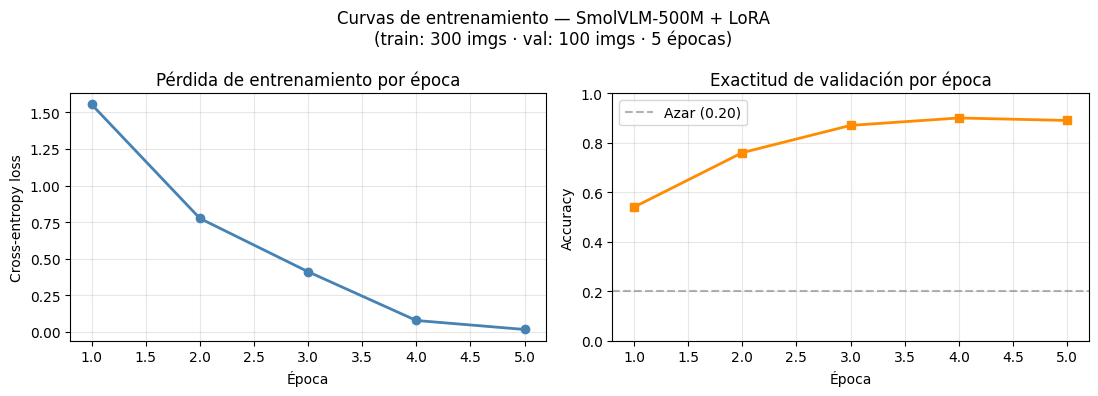

In [25]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
epocas = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epocas, historial['train_loss'], marker='o', color='steelblue', linewidth=2)
ax1.set_title('Pérdida de entrenamiento por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Cross-entropy loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epocas, historial['val_acc'], marker='s', color='darkorange', linewidth=2)
ax2.axhline(y=1.0/len(CLASES), color='gray', linestyle='--', alpha=0.6,
            label=f'Azar ({1.0/len(CLASES):.2f})')
ax2.set_title('Exactitud de validación por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'Curvas de entrenamiento — SmolVLM-500M + LoRA\n'
    f'(train: {len(df_train)} imgs · val: {len(df_val)} imgs · '
    f'{NUM_EPOCHS} épocas)',
    fontsize=12
)
plt.tight_layout()
# plt.savefig(MODEL_SAVE / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

#### **9. Evaluación sobre el conjunto de test**

In [26]:
print('Evaluando sobre el conjunto de test con el mejor checkpoint...\n')
test_acc, y_true, y_pred = evaluar(
    model, dl_test, DEVICE, CHOICE_TOKEN_IDS_TENSOR, desc='Test'
)

baseline_acc = 1.0 / len(CLASES)
mejora_vs_azar = test_acc - baseline_acc

print(f'Test Accuracy:          {test_acc:.4f}  ({test_acc * 100:.2f} %)')
print(f'Accuracy al azar:       {baseline_acc:.4f}  ({baseline_acc * 100:.2f} %)')
print(f'Mejora sobre el azar:   {mejora_vs_azar:+.4f}  '
      f'({mejora_vs_azar * 100:+.2f} pp)')

Evaluando sobre el conjunto de test con el mejor checkpoint...



Test Accuracy:          0.9200  (92.00 %)
Accuracy al azar:       0.2000  (20.00 %)
Mejora sobre el azar:   +0.7200  (+72.00 pp)


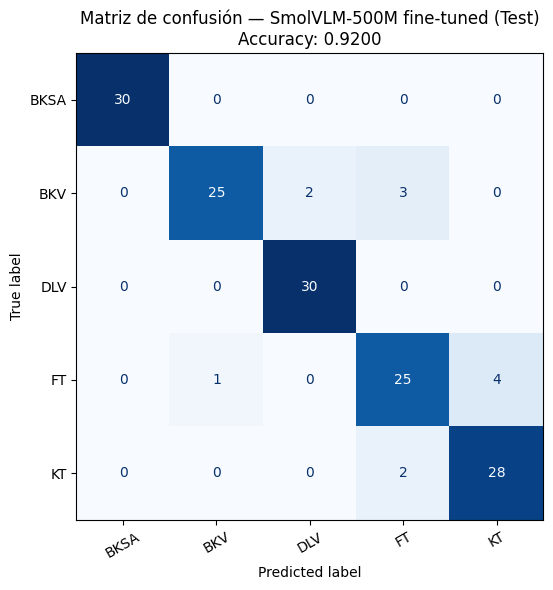

In [27]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
display_labels = [ABREV.get(c, c) for c in CLASES]

cm = confusion_matrix(y_true, y_pred, labels=CLASES)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=display_labels).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30
)
ax.set_title(
    f'Matriz de confusión — SmolVLM-500M fine-tuned (Test)\n'
    f'Accuracy: {test_acc:.4f}'
)
plt.tight_layout()
# plt.savefig(MODEL_SAVE / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

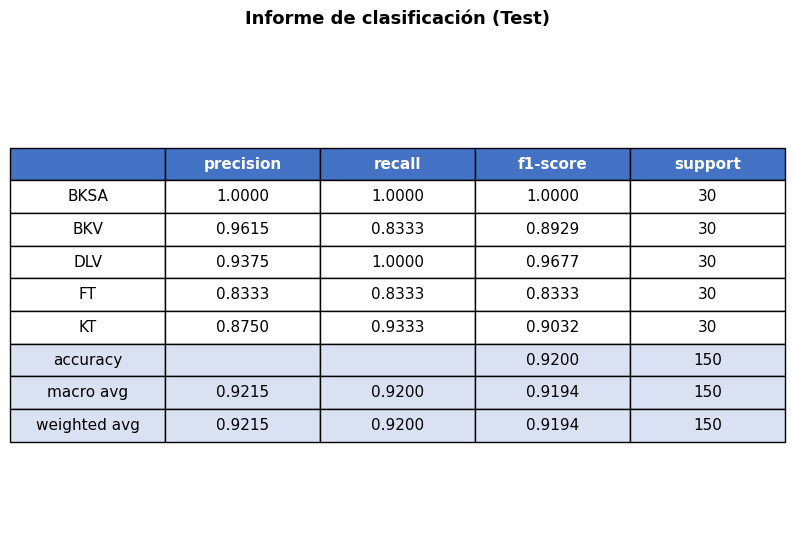

In [28]:
report_dict = classification_report(
    y_true, y_pred,
    labels=CLASES,
    target_names=display_labels,
    digits=4,
    output_dict=True,
)

# Build rows: one per class, then accuracy / macro avg / weighted avg
rows = []
for label in display_labels:
    d = report_dict[label]
    rows.append([label, f"{d['precision']:.4f}", f"{d['recall']:.4f}", f"{d['f1-score']:.4f}", int(d['support'])])

n_samples = int(report_dict['macro avg']['support'])
rows.append(['accuracy', '', '', f"{report_dict['accuracy']:.4f}", n_samples])
for avg_key in ['macro avg', 'weighted avg']:
    d = report_dict[avg_key]
    rows.append([avg_key, f"{d['precision']:.4f}", f"{d['recall']:.4f}", f"{d['f1-score']:.4f}", int(d['support'])])

df_report = pd.DataFrame(rows, columns=['', 'precision', 'recall', 'f1-score', 'support'])

fig, ax = plt.subplots(figsize=(8, len(rows) * 0.52 + 1.5))
ax.axis('off')

tbl = ax.table(
    cellText=df_report.values,
    colLabels=df_report.columns,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.7)

# Header row styling
for col in range(len(df_report.columns)):
    tbl[0, col].set_facecolor('#4472C4')
    tbl[0, col].set_text_props(color='white', fontweight='bold')

# Highlight summary rows (accuracy, macro avg, weighted avg)
for row_idx in range(len(display_labels) + 1, len(rows) + 1):
    for col in range(len(df_report.columns)):
        tbl[row_idx, col].set_facecolor('#D9E1F2')

ax.set_title('Informe de clasificación (Test)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
# plt.savefig(MODEL_SAVE / 'classification_report.png', dpi=150, bbox_inches='tight')
plt.show()

#### **10. Predicciones de muestra**

Se muestran imágenes del test con su predicción y la probabilidad
asociada (softmax de los logits de elección).

- **Borde verde** = predicción correcta
- **Borde rojo** = predicción incorrecta

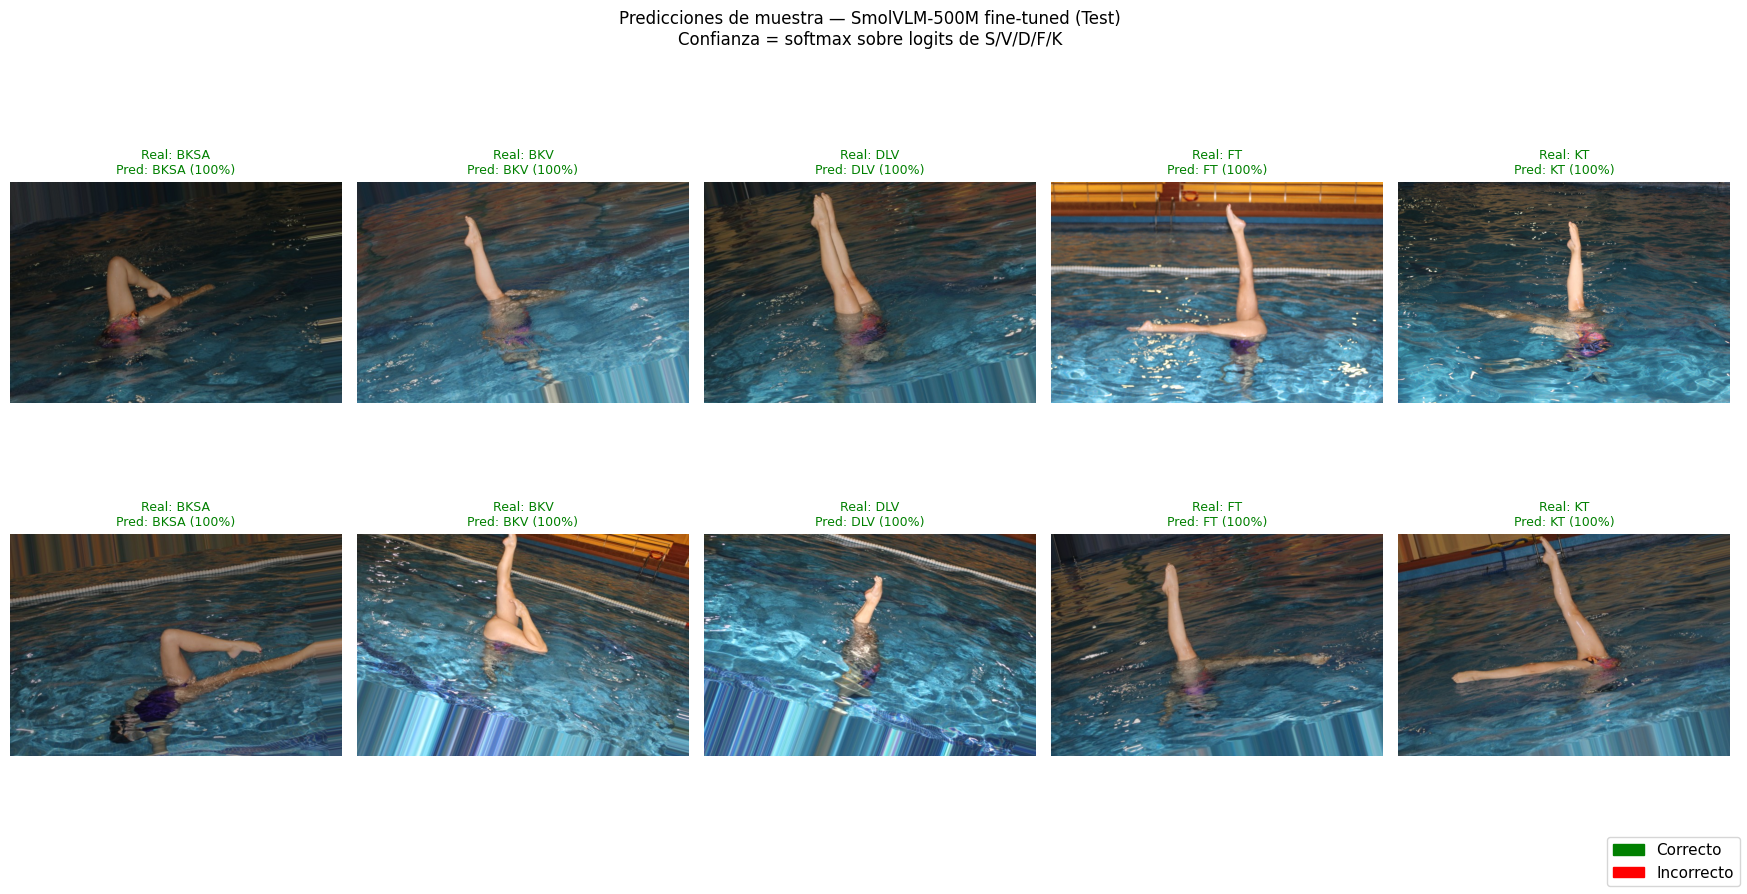

In [29]:
@torch.no_grad()
def mostrar_predicciones(
    df_split: pd.DataFrame,
    model,
    processor,
    device: torch.device,
    clases: list[str],
    choice_ids: torch.Tensor,
    n_por_clase: int = 2,
    seed: int = SEED,
) -> None:
    """
    Muestra una cuadrícula (n_por_clase × n_clases) con predicciones.
    La confianza se obtiene aplicando softmax a los logits de elección.

    Args:
        df_split:    DataFrame de la partición a visualizar.
        model:       Modelo fine-tuned.
        processor:   AutoProcessor de SmolVLM.
        device:      Dispositivo de cómputo.
        clases:      Lista de nombres de clase.
        choice_ids:  Tensor con IDs de tokens S/V/D/F/K.
        n_por_clase: Filas a mostrar por clase.
        seed:        Semilla de muestreo.
    """
    model.eval()

    muestras = pd.concat([
        df_split[df_split['label'] == cls].sample(
            min(n_por_clase, int((df_split['label'] == cls).sum())),
            random_state=seed,
        )
        for cls in clases
    ]).reset_index(drop=True)

    fig, axes = plt.subplots(
        n_por_clase, len(clases),
        figsize=(3.5 * len(clases), 4.5 * n_por_clase),
    )
    if n_por_clase == 1:
        axes = axes.reshape(1, -1)

    for col, cls in enumerate(clases):
        filas_cls = muestras[muestras['label'] == cls].reset_index(drop=True)
        for row in range(n_por_clase):
            ax = axes[row, col]
            if row >= len(filas_cls):
                ax.axis('off')
                continue

            fila  = filas_cls.iloc[row]
            image = Image.open(fila['abs_path']).convert('RGB')

            messages = [{
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': QUESTION_TEXT},
                ],
            }]
            text = processor.apply_chat_template(messages, add_generation_prompt=True)
            enc  = processor(
                text=text, images=[image], return_tensors='pt',
                padding='max_length', max_length=MAX_LENGTH, truncation=True,
            ).to(device)

            outputs       = model(**enc)
            last_logits   = outputs.logits[0, -1, :].float()
            choice_logits = last_logits[choice_ids]
            probs         = F.softmax(choice_logits, dim=-1)
            pred_idx      = probs.argmax().item()
            pred_cls      = IDX2CLS[pred_idx]
            confianza     = probs[pred_idx].item()

            correcto = pred_cls == cls
            color    = 'green' if correcto else 'red'

            ax.imshow(image)
            ax.axis('off')
            ax.set_title(
                f'Real: {ABREV.get(cls, cls)}\n'
                f'Pred: {ABREV.get(pred_cls, pred_cls)} ({confianza:.0%})',
                fontsize=9, color=color,
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

    fig.legend(
        handles=[
            mpatches.Patch(color='green', label='Correcto'),
            mpatches.Patch(color='red',   label='Incorrecto'),
        ],
        loc='lower right', fontsize=11,
    )
    labels_str = '/'.join(CHOICE_LABELS)
    plt.suptitle(
        f'Predicciones de muestra — SmolVLM-500M fine-tuned (Test)\n'
        f'Confianza = softmax sobre logits de {labels_str}',
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(MODEL_SAVE / 'predicciones_muestra.png', dpi=150, bbox_inches='tight')
    plt.show()


mostrar_predicciones(
    df_test, model, processor, DEVICE, CLASES,
    CHOICE_TOKEN_IDS_TENSOR, n_por_clase=2
)

#### **11. Guardado del adaptador LoRA**

Solo se guardan los **pesos LoRA** (~pocos MB), no el modelo base completo.
Para inferencia posterior se carga SmolVLM-500M desde HuggingFace Hub
y se fusiona el adaptador.

In [30]:
ruta_final = MODEL_SAVE / 'adaptador_lora_final'
model.save_pretrained(str(ruta_final))
processor.save_pretrained(str(ruta_final))

print(f'Adaptador LoRA guardado en: {ruta_final.resolve()}')

print('''
Para cargar en otra sesión:

    from transformers import AutoProcessor, AutoModelForImageTextToText
    from peft import PeftModel
    import torch

    base  = AutoModelForImageTextToText.from_pretrained(
        'HuggingFaceTB/SmolVLM-500M-Instruct',
        torch_dtype=torch.bfloat16,
    )
    model = PeftModel.from_pretrained(base, 'smolvlm_lora_natacion/adaptador_lora_final')
    proc  = AutoProcessor.from_pretrained('smolvlm_lora_natacion/adaptador_lora_final')

Para fusionar los pesos LoRA en el modelo base (inferencia más rápida):

    model = model.merge_and_unload()
''')

# ── Resumen final ─────────────────────────────────────────────────────────────
print('=' * 55)
print('RESUMEN FINAL')
print('=' * 55)
print(f'Modelo base:            {MODEL_ID}')
print(f'Parámetros entrenados:  {params_entrenables:,}  ({100 * params_entrenables / params_total:.2f} %)')
print(f'Train / Val / Test:     {len(df_train)} / {len(df_val)} / {len(df_test)} imgs')
print(f'Épocas:                 {NUM_EPOCHS}')
print(f'Mejor Val Accuracy:     {mejor_val_acc:.4f}')
print(f'Test Accuracy:          {test_acc:.4f}')
print(f'Accuracy al azar:       {baseline_acc:.4f}')
print('=' * 55)
print('\nPróximos pasos para mejorar el rendimiento:')
print('  1. Aumentar SUBSET_*_PER_CLASS → None para usar el dataset completo')
print('  2. Aumentar NUM_EPOCHS (5 → 10-20)')
print('  3. Aumentar LORA_R (8 → 16-32)')
print('  4. Añadir target_modules=["k_proj", "o_proj"] para más adaptación')
print('  5. Usar bfloat16 en GPU para mayor velocidad')

Adaptador LoRA guardado en: C:\paula\OTROS\TFG_repo\Fine-tunning de vLLM pequeño\smolvlm_lora_natacion\adaptador_lora_final

Para cargar en otra sesión:

    from transformers import AutoProcessor, AutoModelForImageTextToText
    from peft import PeftModel
    import torch

    base  = AutoModelForImageTextToText.from_pretrained(
        'HuggingFaceTB/SmolVLM-500M-Instruct',
        torch_dtype=torch.bfloat16,
    )
    model = PeftModel.from_pretrained(base, 'smolvlm_lora_natacion/adaptador_lora_final')
    proc  = AutoProcessor.from_pretrained('smolvlm_lora_natacion/adaptador_lora_final')

Para fusionar los pesos LoRA en el modelo base (inferencia más rápida):

    model = model.merge_and_unload()

RESUMEN FINAL
Modelo base:            HuggingFaceTB/SmolVLM-500M-Instruct
Parámetros entrenados:  1,114,112  (0.22 %)
Train / Val / Test:     300 / 100 / 150 imgs
Épocas:                 5
Mejor Val Accuracy:     0.9000
Test Accuracy:          0.9200
Accuracy al azar:       0.2000

Próxim